# Decision tree

## Imports

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import export_text

from heart_failure.modeling.models import build_dt_pipeline
from heart_failure.features import get_fe_pipeline
from heart_failure.dataset import split_data
from heart_failure.modeling.train import optuna_search, dt_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, CV_SCORING, F_BETA_THRESHOLD, MIN_RECALL
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX, PROCESSED_DATA_DIR
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold
)
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

2026-06-24 13:52:24.432 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "decision_tree"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")
rem_columns = pd.read_csv(PROCESSED_DATA_DIR / "remaining_cols.csv")
rem_columns = rem_columns.squeeze().to_list()

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

There is no point in selecting a list of rules (features), since they are unique for each fold. Because of this, multicollinearity does not disappear from the data; accordingly, the importance can be spread across several features.

In [ ]:
fe_pipeline = get_fe_pipeline(combine_rules=False)
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_dt_pipeline,
    param_space=dt_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    scoring=CV_SCORING,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
)

In [18]:
print_best_params(study)

Best parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 18, 'model__max_features': 'log2'}
Best score: 0.91529


In [19]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
103,"{'model__max_depth': 8, 'model__min_samples_le...",0.016024,0.915286,0.913591,0.899297,0.940561,0.924862,0.898118,1
119,"{'model__max_depth': 7, 'model__min_samples_le...",0.016024,0.915286,0.913591,0.899297,0.940561,0.924862,0.898118,1
162,"{'model__max_depth': 7, 'model__min_samples_le...",0.016024,0.915286,0.913591,0.899297,0.940561,0.924862,0.898118,1
163,"{'model__max_depth': 7, 'model__min_samples_le...",0.016024,0.915286,0.913591,0.899297,0.940561,0.924862,0.898118,1
164,"{'model__max_depth': 7, 'model__min_samples_le...",0.016024,0.915286,0.913591,0.899297,0.940561,0.924862,0.898118,1


The scores for different trials are very similar. Hyperparameters don't have that much of an impact on the results in this case.

#### Feature importance

In [20]:
tree = model.named_steps["model"]
columns = fe_pipeline.fit_transform(X_train, y_train).columns
pd.Series(tree.feature_importances_, index=columns).sort_values(ascending=False)

remainder__Oldpeak_ChestPainType_te                  0.449699
remainder__Oldpeak_ST_Slope_te                       0.171688
remainder__MaxHR le 150 & FastingBS eq 1             0.104720
remainder__Oldpeak_ExerciseAngina_te                 0.101596
remainder__RestingBP_Sex_te                          0.044988
target_encoder__ST_Slope                             0.037597
remainder__FastingBS_ST_Slope_te                     0.025924
remainder__FastingBS_ChestPainType_te                0.016915
remainder__Oldpeak ge 2 & Age ge 50                  0.013578
remainder__Age_Sex_te                                0.013085
remainder__RestingBP                                 0.012242
remainder__Oldpeak ge 2 & MaxHR le 160               0.003409
remainder__MaxHR_z                                   0.003185
remainder__FastingBS_ExerciseAngina_te               0.000849
remainder__MaxHR_RestingECG_te                       0.000310
remainder__Oldpeak ge 2 & MaxHR le 150               0.000217
remainde

#### Tree visualization

In [21]:
rules = export_text(tree, feature_names=list(fe_pipeline.transform(X_train).columns))
print(rules)

|--- remainder__Oldpeak_ChestPainType_te <= 0.62
|   |--- remainder__MaxHR le 150 & FastingBS eq 1 <= 0.50
|   |   |--- remainder__Oldpeak_ExerciseAngina_te <= 0.64
|   |   |   |--- remainder__Oldpeak_ST_Slope_te <= 0.74
|   |   |   |   |--- remainder__RestingBP <= 151.00
|   |   |   |   |   |--- remainder__RestingBP <= 119.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- remainder__RestingBP >  119.00
|   |   |   |   |   |   |--- remainder__MaxHR_z <= 1.25
|   |   |   |   |   |   |   |--- remainder__Oldpeak_ExerciseAngina_te <= 0.25
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- remainder__Oldpeak_ExerciseAngina_te >  0.25
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- remainder__MaxHR_z >  1.25
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- remainder__RestingBP >  151.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- remainder__Oldpeak_ST_Slope_te >  0.74
|   |   |   |   |--- remainder__F

Many conditions do not affect the final class.

### Threshold searching

In [22]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float64(0.14705882352941177)

## Metrics

In [23]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.865229
recall       0.901685
fpr          0.173010
pr_auc       0.933859
dtype: float64

In [24]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.640000
recall       0.979592
fpr          0.692308
pr_auc       0.890434
dtype: float64

The metrics are too poor. It's impossible to find a balance between the required recall and precision. The PR-AUC is also worse than in previous models. A tree is not suitable in this case.

### Confusion Matrix

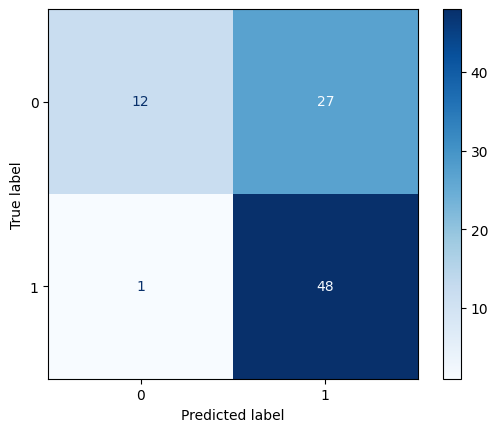

In [12]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

### PR-curve

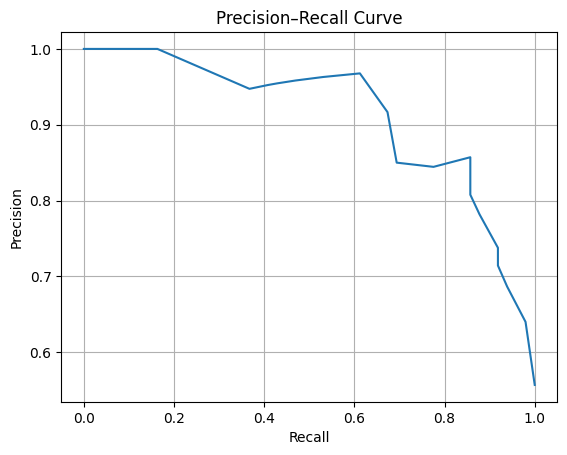

In [13]:
plot_pr_curve(y_val, y_val_proba)

### Test metrics

In [14]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.658065
recall       1.000000
fpr          0.646341
pr_auc       0.870851
dtype: float64

In [ ]:
with mlflow.start_run(run_name=MODEL_NAME) as run:
    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", "all")
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")